# Stats and visuals for the public spine

In [146]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot
import upsetplot


In [175]:
basefilename = '/Users/fionack/Projects/TSO_project/public_spine_data/public_spine'
#basefilename = '/Users/fionack/Projects/TSO_project/tso-database-builder/main_spine.ccew.oscr.ccni.ch.csv'#main_spine.ccew.oscr'
spine_df = pd.read_csv(basefilename+'.spine.csv',usecols=['uid','normalisedname'])
extras_df = pd.read_csv(basefilename+'.supplementary.csv',usecols=['uid','normalisedname','source'])
matches_df = pd.read_csv(basefilename+'.matches.csv')

/var/folders/kx/my6qjd410pg_mks04z_5dm3r0000gn/T/ipykernel_42798/3202743106.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  matches_df = pd.read_csv(basefilename+'.matches.csv')


## Counts per source in main spine

Text(0.5, 1.0, 'Sources found in public spine')

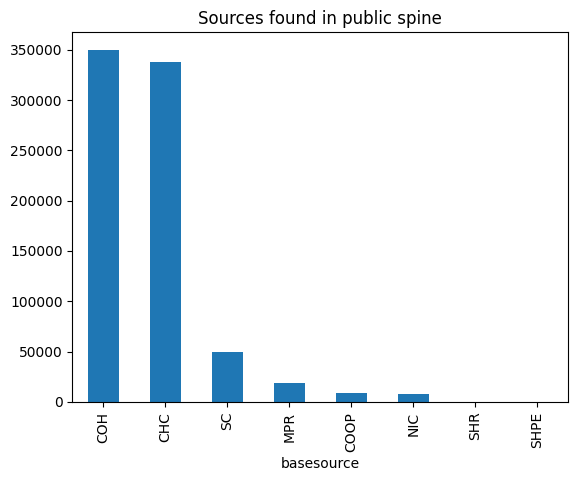

In [176]:
spine_df['basesource'] = spine_df.apply(lambda row: row['uid'].split('-')[1], axis=1)

source_counts = spine_df['basesource'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
source_counts.plot(kind='bar')
pyplot.title('Sources found in public spine')


Text(0.5, 1.0, 'Sources found in supplementary data')

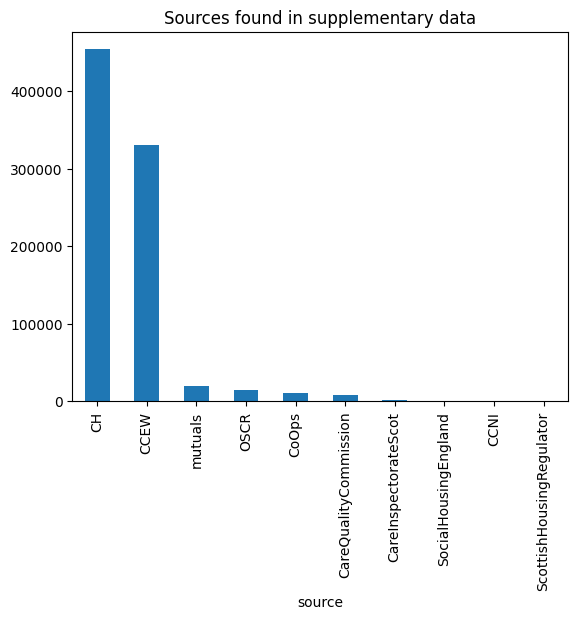

In [177]:

source_counts = extras_df['source'].value_counts(dropna=False)
source_counts = source_counts.rename(index={np.nan: 'NaN'})
source_counts.plot(kind='bar')
pyplot.title('Sources found in supplementary data')


Text(0.5, 1.0, 'Match types found for public spine')

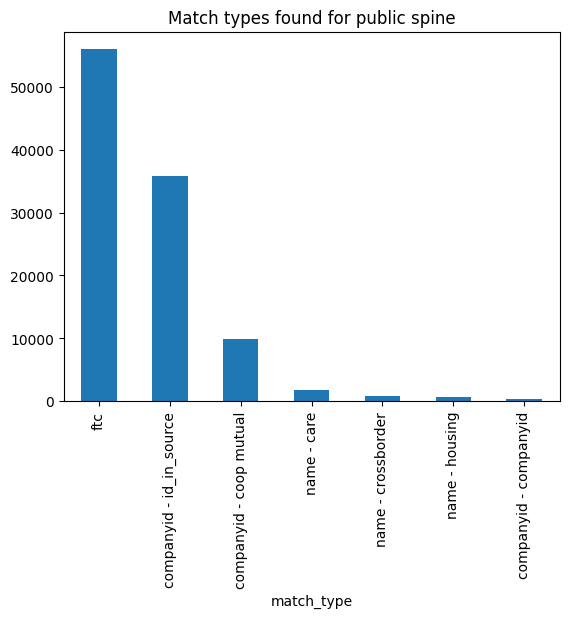

In [178]:

match_types = matches_df['match_type'].value_counts(dropna=False)
match_types = match_types.rename(index={np.nan: 'NaN'})
match_types.plot(kind='bar')
pyplot.title('Match types found for public spine')

# also think of how to plot this so that identical matches are shown in a different way - pairs of organisations which are matched by ftc and also name, for example - this chart doesn't differentiate


In [182]:
def plot_upset_matches(infile):
     #print(type(source_list))
    df = pd.read_csv(infile,usecols=['orgA_source','orgB_source'])
    source_order = {'CCEW': 1, 
                    'OSCR' : 2,
                    'CCNI': 3, 
                    'CH' : 4,
                    'CoOps' : 5,
                    'mutuals' : 6,
                    'ScottishHousingRegulator' : 7,
                    'SocialHousingEngland' : 8,
                    'CareInspectorateScot' : 9,
                    'CareQualityCommission' : 10
                    }

    for s in source_order.keys():
    
        df[s] = (matches_df['orgA_source'] == s) | (matches_df['orgB_source'] == s)
        # now df has a column for each source type, indicating whether uid is from source or not
    
    df.drop(labels=['orgA_source','orgB_source'],axis=1, inplace=True)
    source_list = df.columns.tolist()
    # Group by source_list and get the size
    df_grouped = df.groupby(source_list).size()
    
    upsetplot.plot(df_grouped, orientation='horizontal')#, sort_by=source_order)

    pyplot.title(os.path.basename(infile))
    pyplot.show()


/Users/fionack/Projects/TSO_project/tso-database-builder/.tso/lib/python3.11/site-packages/upsetplot/plotting.py:662: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['#0000002e' 'black' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' 'black' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' 'black' 'black' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 'black' '#0000002e' 'black' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' 'black' '#0000002e'
 '#0000002e' 'black' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 '#0000002e' '#0000002e' '#0000002e' 'black' '#0000002e' 'black'
 '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e' '#0000002e'
 'black' '#0000002e' '#0000002e' '#0000002e' 'black' '#0000002e'
 '#000000

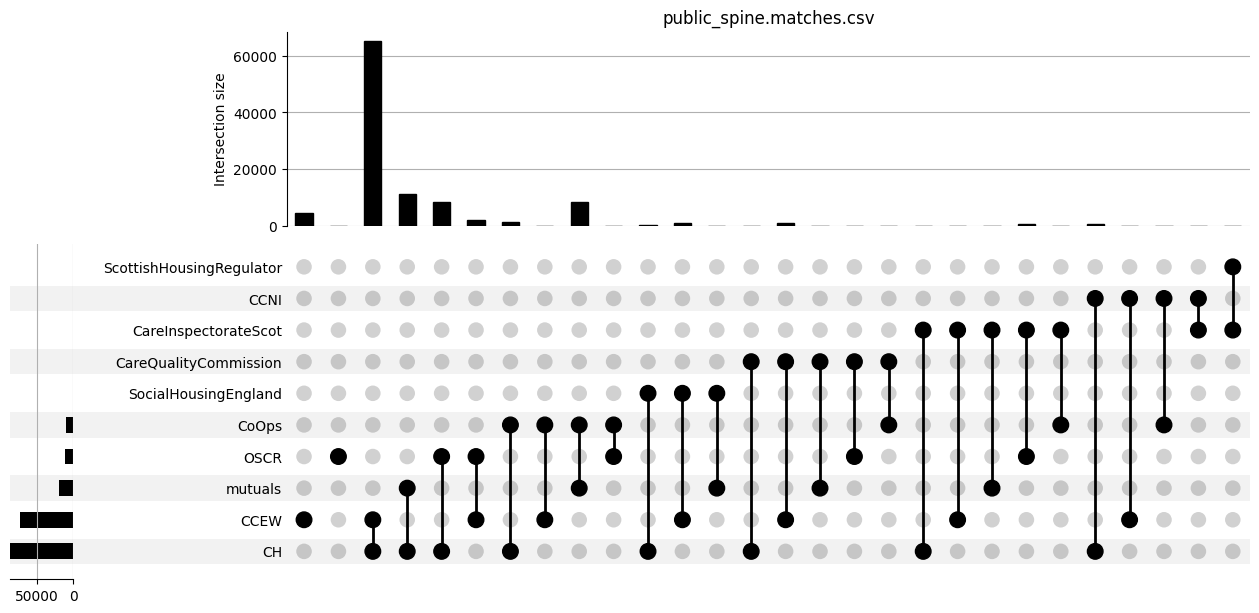

In [183]:
plot_upset_matches(basefilename+'.matches.csv')

In [181]:

sources = np.union1d(matches_df['orgB_source'].unique(), matches_df['orgA_source'].unique())

print(sources)

['CCEW' 'CCNI' 'CH' 'CareInspectorateScot' 'CareQualityCommission' 'CoOps'
 'OSCR' 'ScottishHousingRegulator' 'SocialHousingEngland' 'mutuals']
